# FRA Risk Intelligence Platform

## AI Risk Analysis

This notebook implements the AI components of the FRA Risk Intelligence Platform.

The system analyzes two main risk factors:

1. Complaints Risk — NLP-based analysis
2. Financial Risk — Financial data analysis

The outputs are combined to generate an overall risk score and early warning level.

## 1. Libraries and Setup

In [1]:
import numpy as np
import pandas as pd

In [2]:
import os

for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# 2. Complaints Risk Analysis

This section analyzes customer complaints to identify complaint patterns,
severity, trends, and potential early warning signals.

**Responsible:** Darine

In [3]:
import pandas as pd

complaints = pd.read_csv("complaints.csv")

complaints.head()

,id,company_id,complaint_date,category,description,sentiment,severity,status,source
0,1,12,2025-07-09,loan,My installment amount appears different from t...,negative,low,open,branch
1,2,15,2025-01-21,billing,A payment was recorded incorrectly on my account.,negative,medium,open,hotline
2,3,9,2025-12-06,loan,I requested a copy of my loan agreement but ha...,positive,medium,open,website
3,4,15,2026-01-23,billing,A payment was recorded incorrectly on my account.,negative,low,dismissed,website
4,5,2,2025-07-21,service,I have been waiting too long for a response fr...,negative,low,resolved,branch


In [4]:
complaints.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   id              1200 non-null   int64 
 1   company_id      1200 non-null   int64 
 2   complaint_date  1200 non-null   object
 3   category        1200 non-null   object
 4   description     1200 non-null   object
 5   sentiment       1200 non-null   object
 6   severity        1200 non-null   object
 7   status          1200 non-null   object
 8   source          1200 non-null   object
dtypes: int64(2), object(7)
memory usage: 84.5+ KB


In [5]:
complaints.describe(include="all")

,id,company_id,complaint_date,category,description,sentiment,severity,status,source
count,1200.000000,1200.000000,1200,1200,1200,1200,1200,1200,1200
unique,NaN,NaN,533,6,171,3,3,3,4
top,NaN,NaN,2026-05-18,loan,I was charged after the payment had already be...,negative,medium,resolved,website
freq,NaN,NaN,8,269,48,865,533,652,385
mean,600.500000,11.055000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,346.554469,5.737253,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,1.000000,1.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,300.750000,6.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,600.500000,11.500000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,900.250000,16.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [6]:
print("Columns:")
print(complaints.columns.tolist())

print("\nMissing Values:")
print(complaints.isnull().sum())

print("\nShape:")
print(complaints.shape)

Columns:
['id', 'company_id', 'complaint_date', 'category', 'description', 'sentiment', 'severity', 'status', 'source']

Missing Values:
id                0
company_id        0
complaint_date    0
category          0
description       0
sentiment         0
severity          0
status            0
source            0
dtype: int64

Shape:
(1200, 9)


In [7]:
print("Number of rows:", complaints.shape[0])
print("Number of columns:", complaints.shape[1])

Number of rows: 1200
Number of columns: 9


In [8]:
print("Severity values:")
print(complaints["severity"].value_counts())

print("\nSentiment values:")
print(complaints["sentiment"].value_counts())

print("\nStatus values:")
print(complaints["status"].value_counts())

print("\nCategory values:")
print(complaints["category"].value_counts())

print("\nSource values:")
print(complaints["source"].value_counts())

Severity values:
severity
medium    533
low       448
high      219
Name: count, dtype: int64

Sentiment values:
sentiment
negative    865
neutral     244
positive     91
Name: count, dtype: int64

Status values:
status
resolved     652
open         437
dismissed    111
Name: count, dtype: int64

Category values:
category
loan         269
service      224
payment      223
billing      206
insurance    166
fraud        112
Name: count, dtype: int64

Source values:
source
website         385
hotline         345
branch          308
social_media    162
Name: count, dtype: int64


## 2.1 Complaint Risk Feature Engineering

We transform complaint-level data into company-level risk indicators.

The main indicators include:
- Complaint volume
- Negative sentiment ratio
- High severity ratio
- Open complaint ratio
- Fraud complaint ratio
- Recent complaint activity

In [9]:
# Make a copy for analysis
complaints_risk = complaints.copy()

# Convert date column to datetime
complaints_risk["complaint_date"] = pd.to_datetime(
    complaints_risk["complaint_date"]
)

complaints_risk.head()

,id,company_id,complaint_date,category,description,sentiment,severity,status,source
0,1,12,2025-07-09,loan,My installment amount appears different from t...,negative,low,open,branch
1,2,15,2025-01-21,billing,A payment was recorded incorrectly on my account.,negative,medium,open,hotline
2,3,9,2025-12-06,loan,I requested a copy of my loan agreement but ha...,positive,medium,open,website
3,4,15,2026-01-23,billing,A payment was recorded incorrectly on my account.,negative,low,dismissed,website
4,5,2,2025-07-21,service,I have been waiting too long for a response fr...,negative,low,resolved,branch


In [10]:
company_complaints = complaints_risk.groupby("company_id").agg(
    complaint_count=("id", "count"),
    negative_complaints=("sentiment", lambda x: (x == "negative").sum()),
    high_severity=("severity", lambda x: (x == "high").sum()),
    open_complaints=("status", lambda x: (x == "open").sum()),
    fraud_complaints=("category", lambda x: (x == "fraud").sum())
).reset_index()

company_complaints.head()

,company_id,complaint_count,negative_complaints,high_severity,open_complaints,fraud_complaints
0,1,54,35,6,16,4
1,2,61,49,11,27,6
2,3,49,30,3,16,3
3,4,47,32,11,15,6
4,5,46,36,10,18,3


In [11]:
company_complaints["negative_ratio"] = (
    company_complaints["negative_complaints"]
    / company_complaints["complaint_count"]
)

company_complaints["high_severity_ratio"] = (
    company_complaints["high_severity"]
    / company_complaints["complaint_count"]
)

company_complaints["open_ratio"] = (
    company_complaints["open_complaints"]
    / company_complaints["complaint_count"]
)

company_complaints["fraud_ratio"] = (
    company_complaints["fraud_complaints"]
    / company_complaints["complaint_count"]
)

company_complaints.head()

,company_id,complaint_count,negative_complaints,high_severity,open_complaints,fraud_complaints,negative_ratio,high_severity_ratio,open_ratio,fraud_ratio
0,1,54,35,6,16,4,0.648148,0.111111,0.296296,0.074074
1,2,61,49,11,27,6,0.803279,0.180328,0.442623,0.098361
2,3,49,30,3,16,3,0.612245,0.061224,0.326531,0.061224
3,4,47,32,11,15,6,0.680851,0.234043,0.319149,0.127660
4,5,46,36,10,18,3,0.782609,0.217391,0.391304,0.065217


## 2.2 Complaint Trend Analysis

We analyze complaint activity over time to detect sudden increases
that may indicate an emerging risk.

In [12]:
# Create monthly complaint counts for each company

complaints_risk["month"] = complaints_risk["complaint_date"].dt.to_period("M")

monthly_complaints = (
    complaints_risk
    .groupby(["company_id", "month"])
    .size()
    .reset_index(name="monthly_complaints")
)

monthly_complaints.head(10)

,company_id,month,monthly_complaints
0,1,2025-01,2
1,1,2025-02,3
2,1,2025-03,2
3,1,2025-04,4
4,1,2025-05,1
5,1,2025-06,4
6,1,2025-07,5
7,1,2025-08,2
8,1,2025-09,3
9,1,2025-10,2


In [13]:
monthly_complaints["complaint_growth"] = (
    monthly_complaints
    .groupby("company_id")["monthly_complaints"]
    .pct_change()
)

monthly_complaints.head(10)

,company_id,month,monthly_complaints,complaint_growth
0,1,2025-01,2,NaN
1,1,2025-02,3,0.500000
2,1,2025-03,2,-0.333333
3,1,2025-04,4,1.000000
4,1,2025-05,1,-0.750000
5,1,2025-06,4,3.000000
6,1,2025-07,5,0.250000
7,1,2025-08,2,-0.600000
8,1,2025-09,3,0.500000
9,1,2025-10,2,-0.333333


In [14]:
latest_trend = (
    monthly_complaints
    .sort_values(["company_id", "month"])
    .groupby("company_id")
    .tail(1)
    [["company_id", "monthly_complaints", "complaint_growth"]]
)

latest_trend.head()

,company_id,monthly_complaints,complaint_growth
18,1,5,0.250000
37,2,4,1.000000
55,3,3,-0.400000
73,4,2,-0.333333
93,5,1,-0.666667


In [15]:
company_complaints = company_complaints.merge(
    latest_trend,
    on="company_id",
    how="left"
)

company_complaints.head()

,company_id,complaint_count,negative_complaints,high_severity,open_complaints,fraud_complaints,negative_ratio,high_severity_ratio,open_ratio,fraud_ratio,monthly_complaints,complaint_growth
0,1,54,35,6,16,4,0.648148,0.111111,0.296296,0.074074,5,0.250000
1,2,61,49,11,27,6,0.803279,0.180328,0.442623,0.098361,4,1.000000
2,3,49,30,3,16,3,0.612245,0.061224,0.326531,0.061224,3,-0.400000
3,4,47,32,11,15,6,0.680851,0.234043,0.319149,0.127660,2,-0.333333
4,5,46,36,10,18,3,0.782609,0.217391,0.391304,0.065217,1,-0.666667


## 2.3 Complaint Risk Score

We calculate a complaint risk score for each company based on multiple
risk indicators:

- Complaint volume
- Negative sentiment ratio
- High severity ratio
- Open complaint ratio
- Fraud complaint ratio
- Recent complaint growth

The final Complaint Risk Score ranges from 0 to 100.

In [16]:
# Function to normalize a column to a 0-100 risk scale

def normalize_score(series):
    min_value = series.min()
    max_value = series.max()

    if max_value == min_value:
        return pd.Series(0, index=series.index)

    return ((series - min_value) / (max_value - min_value)) * 100

In [17]:
# Normalize complaint risk indicators

company_complaints["volume_score"] = normalize_score(
    company_complaints["complaint_count"]
)

company_complaints["negative_score"] = normalize_score(
    company_complaints["negative_ratio"]
)

company_complaints["severity_score"] = normalize_score(
    company_complaints["high_severity_ratio"]
)

company_complaints["open_score"] = normalize_score(
    company_complaints["open_ratio"]
)

company_complaints["fraud_score"] = normalize_score(
    company_complaints["fraud_ratio"]
)

# For complaint growth:
# Negative growth should not increase risk.
growth_for_score = company_complaints["complaint_growth"].fillna(0).clip(lower=0)

company_complaints["growth_score"] = normalize_score(
    growth_for_score
)

company_complaints.head()

,company_id,complaint_count,negative_complaints,high_severity,open_complaints,fraud_complaints,negative_ratio,high_severity_ratio,open_ratio,fraud_ratio,monthly_complaints,complaint_growth,volume_score,negative_score,severity_score,open_score,fraud_score,growth_score
0,1,54,35,6,16,4,0.648148,0.111111,0.296296,0.074074,5,0.250000,27.586207,18.794188,25.882353,0.000000,32.026144,8.333333
1,2,61,49,11,27,6,0.803279,0.180328,0.442623,0.098361,4,1.000000,51.724138,100.000000,61.793635,100.000000,56.027001,33.333333
2,3,49,30,3,16,3,0.612245,0.061224,0.326531,0.061224,3,-0.400000,10.344828,0.000000,0.000000,20.662207,19.327731,0.000000
3,4,47,32,11,15,6,0.680851,0.234043,0.319149,0.127660,2,-0.333333,3.448276,35.913105,89.662078,15.617551,84.981227,0.000000
4,5,46,36,10,18,3,0.782609,0.217391,0.391304,0.065217,1,-0.666667,0.000000,89.179928,81.023018,64.928739,23.273657,0.000000


In [18]:
company_complaints["complaint_risk_score"] = (
    0.20 * company_complaints["volume_score"]
    + 0.20 * company_complaints["negative_score"]
    + 0.20 * company_complaints["severity_score"]
    + 0.15 * company_complaints["open_score"]
    + 0.10 * company_complaints["fraud_score"]
    + 0.15 * company_complaints["growth_score"]
)

# Round the score
company_complaints["complaint_risk_score"] = (
    company_complaints["complaint_risk_score"].round(2)
)

company_complaints[
    ["company_id", "complaint_risk_score"]
].sort_values(
    "complaint_risk_score",
    ascending=False
).head(10)

,company_id,complaint_risk_score
12,13,73.10
11,12,69.29
1,2,68.31
19,20,62.73
18,19,61.06
6,7,58.24
14,15,55.25
15,16,53.33
16,17,52.83
13,14,50.49


## 2.4 Complaint Risk Level

Companies are classified into four complaint risk levels based on
their complaint risk score.

In [19]:
def get_complaint_risk_level(score):
    if score >= 85:
        return "Critical"
    elif score >= 70:
        return "High"
    elif score >= 40:
        return "Medium"
    else:
        return "Low"


company_complaints["complaint_risk_level"] = (
    company_complaints["complaint_risk_score"]
    .apply(get_complaint_risk_level)
)

company_complaints[
    [
        "company_id",
        "complaint_risk_score",
        "complaint_risk_level"
    ]
].sort_values(
    "complaint_risk_score",
    ascending=False
).head(10)

,company_id,complaint_risk_score,complaint_risk_level
12,13,73.10,High
11,12,69.29,Medium
1,2,68.31,Medium
19,20,62.73,Medium
18,19,61.06,Medium
6,7,58.24,Medium
14,15,55.25,Medium
15,16,53.33,Medium
16,17,52.83,Medium
13,14,50.49,Medium


## 2.5 Complaint Risk Drivers

This section identifies the main complaint-related factors contributing
to each company's risk score.

In [20]:
risk_columns = [
    "volume_score",
    "negative_score",
    "severity_score",
    "open_score",
    "fraud_score",
    "growth_score"
]

company_complaints[
    ["company_id", "complaint_risk_score", "complaint_risk_level"] + risk_columns
].sort_values(
    "complaint_risk_score",
    ascending=False
).head(10)

,company_id,complaint_risk_score,complaint_risk_level,volume_score,negative_score,severity_score,open_score,fraud_score,growth_score
12,13,73.10,High,75.862069,72.110333,82.681661,58.811325,31.487889,100.000000
11,12,69.29,Medium,58.620690,70.033080,100.000000,90.397155,100.000000,0.000000
1,2,68.31,Medium,51.724138,100.000000,61.793635,100.000000,56.027001,33.333333
19,20,62.73,Medium,100.000000,63.385873,78.917647,43.535270,77.411765,0.000000
18,19,61.06,Medium,68.965517,76.075996,86.149733,56.374953,63.636364,0.000000
6,7,58.24,Medium,62.068966,55.751970,49.301471,64.464471,51.470588,66.666667
14,15,55.25,Medium,100.000000,35.467601,58.164706,34.423237,51.058824,41.666667
15,16,53.33,Medium,55.172414,84.774871,68.652751,28.985410,22.580645,33.333333
16,17,52.83,Medium,93.103448,66.732241,60.628525,31.552322,40.048348,0.000000
13,14,50.49,Medium,82.758621,30.980736,42.352941,80.634262,71.764706,0.000000


In [21]:
# Calculate the contribution of each risk factor

company_complaints["volume_contribution"] = (
    company_complaints["volume_score"] * 0.20
)

company_complaints["negative_contribution"] = (
    company_complaints["negative_score"] * 0.20
)

company_complaints["severity_contribution"] = (
    company_complaints["severity_score"] * 0.20
)

company_complaints["open_contribution"] = (
    company_complaints["open_score"] * 0.15
)

company_complaints["fraud_contribution"] = (
    company_complaints["fraud_score"] * 0.10
)

company_complaints["growth_contribution"] = (
    company_complaints["growth_score"] * 0.15
)

In [22]:
risk_contribution_columns = {
    "volume_contribution": "High complaint volume",
    "negative_contribution": "High negative sentiment",
    "severity_contribution": "High severity complaints",
    "open_contribution": "High number of open complaints",
    "fraud_contribution": "Fraud-related complaints",
    "growth_contribution": "Increasing complaint activity"
}

def get_risk_drivers(row, top_n=3):
    contributions = {
        label: row[column]
        for column, label in risk_contribution_columns.items()
    }

    sorted_drivers = sorted(
        contributions.items(),
        key=lambda x: x[1],
        reverse=True
    )

    return [driver for driver, score in sorted_drivers[:top_n]]


company_complaints["risk_drivers"] = company_complaints.apply(
    get_risk_drivers,
    axis=1
)

company_complaints[
    [
        "company_id",
        "complaint_risk_score",
        "complaint_risk_level",
        "risk_drivers"
    ]
].sort_values(
    "complaint_risk_score",
    ascending=False
).head(10)

,company_id,complaint_risk_score,complaint_risk_level,risk_drivers
12,13,73.10,High,"[High severity complaints, High complaint volu..."
11,12,69.29,Medium,"[High severity complaints, High negative senti..."
1,2,68.31,Medium,"[High negative sentiment, High number of open ..."
19,20,62.73,Medium,"[High complaint volume, High severity complain..."
18,19,61.06,Medium,"[High severity complaints, High negative senti..."
6,7,58.24,Medium,"[High complaint volume, High negative sentimen..."
14,15,55.25,Medium,"[High complaint volume, High severity complain..."
15,16,53.33,Medium,"[High negative sentiment, High severity compla..."
16,17,52.83,Medium,"[High complaint volume, High negative sentimen..."
13,14,50.49,Medium,"[High complaint volume, High number of open co..."


## 2.6 Complaint Risk Drivers and Early Warning

This section identifies the main complaint-related factors contributing
to each company's complaint risk score and generates an early warning
message for companies with high or critical complaint risk.

In [23]:
def generate_complaint_warning(row):
    if row["complaint_risk_level"] in ["High", "Critical"]:
        drivers = ", ".join(row["risk_drivers"])
        return (
            f"Early Warning: {row['complaint_risk_level']} complaint risk. "
            f"Main drivers: {drivers}."
        )
    
    return "No high-risk complaint warning."


company_complaints["complaint_early_warning"] = (
    company_complaints.apply(
        generate_complaint_warning,
        axis=1
    )
)

company_complaints[
    [
        "company_id",
        "complaint_risk_score",
        "complaint_risk_level",
        "risk_drivers",
        "complaint_early_warning"
    ]
].sort_values(
    "complaint_risk_score",
    ascending=False
)

,company_id,complaint_risk_score,complaint_risk_level,risk_drivers,complaint_early_warning
12,13,73.10,High,"[High severity complaints, High complaint volu...",Early Warning: High complaint risk. Main drive...
11,12,69.29,Medium,"[High severity complaints, High negative senti...",No high-risk complaint warning.
1,2,68.31,Medium,"[High negative sentiment, High number of open ...",No high-risk complaint warning.
19,20,62.73,Medium,"[High complaint volume, High severity complain...",No high-risk complaint warning.
18,19,61.06,Medium,"[High severity complaints, High negative senti...",No high-risk complaint warning.
6,7,58.24,Medium,"[High complaint volume, High negative sentimen...",No high-risk complaint warning.
14,15,55.25,Medium,"[High complaint volume, High severity complain...",No high-risk complaint warning.
15,16,53.33,Medium,"[High negative sentiment, High severity compla...",No high-risk complaint warning.
16,17,52.83,Medium,"[High complaint volume, High negative sentimen...",No high-risk complaint warning.
13,14,50.49,Medium,"[High complaint volume, High number of open co...",No high-risk complaint warning.


## 2.7 Final Complaint Risk Output

The final complaint risk output will be used later to combine complaint
risk with financial risk and calculate the overall company risk.

In [24]:
complaint_risk_output = company_complaints[
    [
        "company_id",
        "complaint_risk_score",
        "complaint_risk_level",
        "risk_drivers",
        "complaint_early_warning"
    ]
].copy()

complaint_risk_output = complaint_risk_output.sort_values(
    "complaint_risk_score",
    ascending=False
)

complaint_risk_output.head(10)

,company_id,complaint_risk_score,complaint_risk_level,risk_drivers,complaint_early_warning
12,13,73.10,High,"[High severity complaints, High complaint volu...",Early Warning: High complaint risk. Main drive...
11,12,69.29,Medium,"[High severity complaints, High negative senti...",No high-risk complaint warning.
1,2,68.31,Medium,"[High negative sentiment, High number of open ...",No high-risk complaint warning.
19,20,62.73,Medium,"[High complaint volume, High severity complain...",No high-risk complaint warning.
18,19,61.06,Medium,"[High severity complaints, High negative senti...",No high-risk complaint warning.
6,7,58.24,Medium,"[High complaint volume, High negative sentimen...",No high-risk complaint warning.
14,15,55.25,Medium,"[High complaint volume, High severity complain...",No high-risk complaint warning.
15,16,53.33,Medium,"[High negative sentiment, High severity compla...",No high-risk complaint warning.
16,17,52.83,Medium,"[High complaint volume, High negative sentimen...",No high-risk complaint warning.
13,14,50.49,Medium,"[High complaint volume, High number of open co...",No high-risk complaint warning.


# 3. Financial Risk Analysis

This section analyzes financial indicators to identify potential financial
distress and risk signals.

**Responsible:** Rawan

In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [26]:

fd = pd.read_csv("financial_data.csv")

companies = pd.read_csv("companies.csv")

companies.head()
fd.head()

,id,company_id,period,revenue,net_profit,total_assets,total_liabilities,total_debt,equity,cash,current_assets,current_liabilities
0,1,1,2024Q1,11794216.19,852460.59,39876783.98,24018740.84,20094923.92,15858043.14,4472316.69,17412679.28,10409195.99
1,2,1,2024Q2,11847692.69,822109.59,38816164.07,23763085.46,19786316.74,15053078.61,4548943.66,11768247.68,10921750.79
2,3,1,2024Q3,12313058.08,1086301.02,39403431.60,23944945.70,20735269.60,15458485.90,4587645.51,10227552.42,9527055.82
3,4,1,2024Q4,12252894.47,1188972.75,39735785.44,25586654.36,20875158.22,14149131.08,4608420.10,12404162.00,15251185.78
4,5,1,2025Q1,12278766.00,1090621.88,39894077.77,26306972.07,21718194.35,13587105.70,4772316.70,16583525.61,12744231.70


In [27]:
print("Financial Data Columns:")
print(fd.columns.tolist())

print("\nFinancial Data Types:")
print(fd.dtypes)

print("\nMissing Values:")
print(fd.isnull().sum())

print("\nDuplicate Rows:")
print(fd.duplicated().sum())

print("\nNumber of Companies:")
print(fd["company_id"].nunique())

print("\nPeriods:")
print(fd["period"].value_counts().sort_index())

Financial Data Columns:
['id', 'company_id', 'period', 'revenue', 'net_profit', 'total_assets', 'total_liabilities', 'total_debt', 'equity', 'cash', 'current_assets', 'current_liabilities']

Financial Data Types:
id                       int64
company_id               int64
period                  object
revenue                float64
net_profit             float64
total_assets           float64
total_liabilities      float64
total_debt             float64
equity                 float64
cash                   float64
current_assets         float64
current_liabilities    float64
dtype: object

Missing Values:
id                     0
company_id             0
period                 0
revenue                0
net_profit             0
total_assets           0
total_liabilities      0
total_debt             0
equity                 0
cash                   0
current_assets         0
current_liabilities    0
dtype: int64

Duplicate Rows:
0

Number of Companies:
20

Periods:
period
2024Q1    

In [28]:
#Validating to check for errors
required_columns = [
    "id",
    "company_id",
    "period",
    "revenue",
    "net_profit",
    "total_assets",
    "total_liabilities",
    "total_debt",
    "equity",
    "cash",
    "current_assets",
    "current_liabilities"
]

missing_columns = [col for col in required_columns if col not in fd.columns]

if len(missing_columns) == 0:
    print("All required financial columns are available.")
else:
    print("Missing columns:", missing_columns)

All required financial columns are available.


In [29]:
#Data Cleaning
fd = fd.copy()

financial_cols = [
    "revenue",
    "net_profit",
    "total_assets",
    "total_liabilities",
    "total_debt",
    "equity",
    "cash",
    "current_assets",
    "current_liabilities"
]

for col in financial_cols:
    fd[col] = pd.to_numeric(fd[col], errors="coerce")

fd = fd.drop_duplicates()

print("Shape after cleaning:", fd.shape)
print("\nMissing values after cleaning:")
print(fd.isnull().sum())

Shape after cleaning: (200, 12)

Missing values after cleaning:
id                     0
company_id             0
period                 0
revenue                0
net_profit             0
total_assets           0
total_liabilities      0
total_debt             0
equity                 0
cash                   0
current_assets         0
current_liabilities    0
dtype: int64


In [30]:
# Period Handling and Sorting
fd["period"] = fd["period"].astype(str)
fd["period"] = pd.PeriodIndex(fd["period"], freq="Q")

fd = fd.sort_values(["company_id", "period"]).reset_index(drop=True)

display(fd.head(12))

,id,company_id,period,revenue,net_profit,total_assets,total_liabilities,total_debt,equity,cash,current_assets,current_liabilities
0,1,1,2024Q1,11794216.19,852460.59,39876783.98,24018740.84,20094923.92,15858043.14,4472316.69,17412679.28,10409195.99
1,2,1,2024Q2,11847692.69,822109.59,38816164.07,23763085.46,19786316.74,15053078.61,4548943.66,11768247.68,10921750.79
2,3,1,2024Q3,12313058.08,1086301.02,39403431.60,23944945.70,20735269.60,15458485.90,4587645.51,10227552.42,9527055.82
3,4,1,2024Q4,12252894.47,1188972.75,39735785.44,25586654.36,20875158.22,14149131.08,4608420.10,12404162.00,15251185.78
4,5,1,2025Q1,12278766.00,1090621.88,39894077.77,26306972.07,21718194.35,13587105.70,4772316.70,16583525.61,12744231.70
5,6,1,2025Q2,12346132.81,974409.11,40114388.78,27485685.19,21518992.65,12628703.59,4923852.30,11328040.11,14435605.29
6,7,1,2025Q3,12348587.90,826255.75,41157309.67,25443792.06,22124845.70,15713517.61,4980393.68,15486486.75,12699734.49
7,8,1,2025Q4,12252829.58,824461.36,41710840.43,28725847.75,21611606.11,12984992.68,5156413.98,13702229.63,12146612.59
8,9,1,2026Q1,12254520.59,1042875.87,40200086.11,27460204.02,22494085.08,12739882.08,5325097.39,11017560.74,10287534.77
9,10,1,2026Q2,12078403.68,650990.90,40124494.59,30630308.09,23156124.46,9494186.50,5404240.19,12748701.67,11689140.14


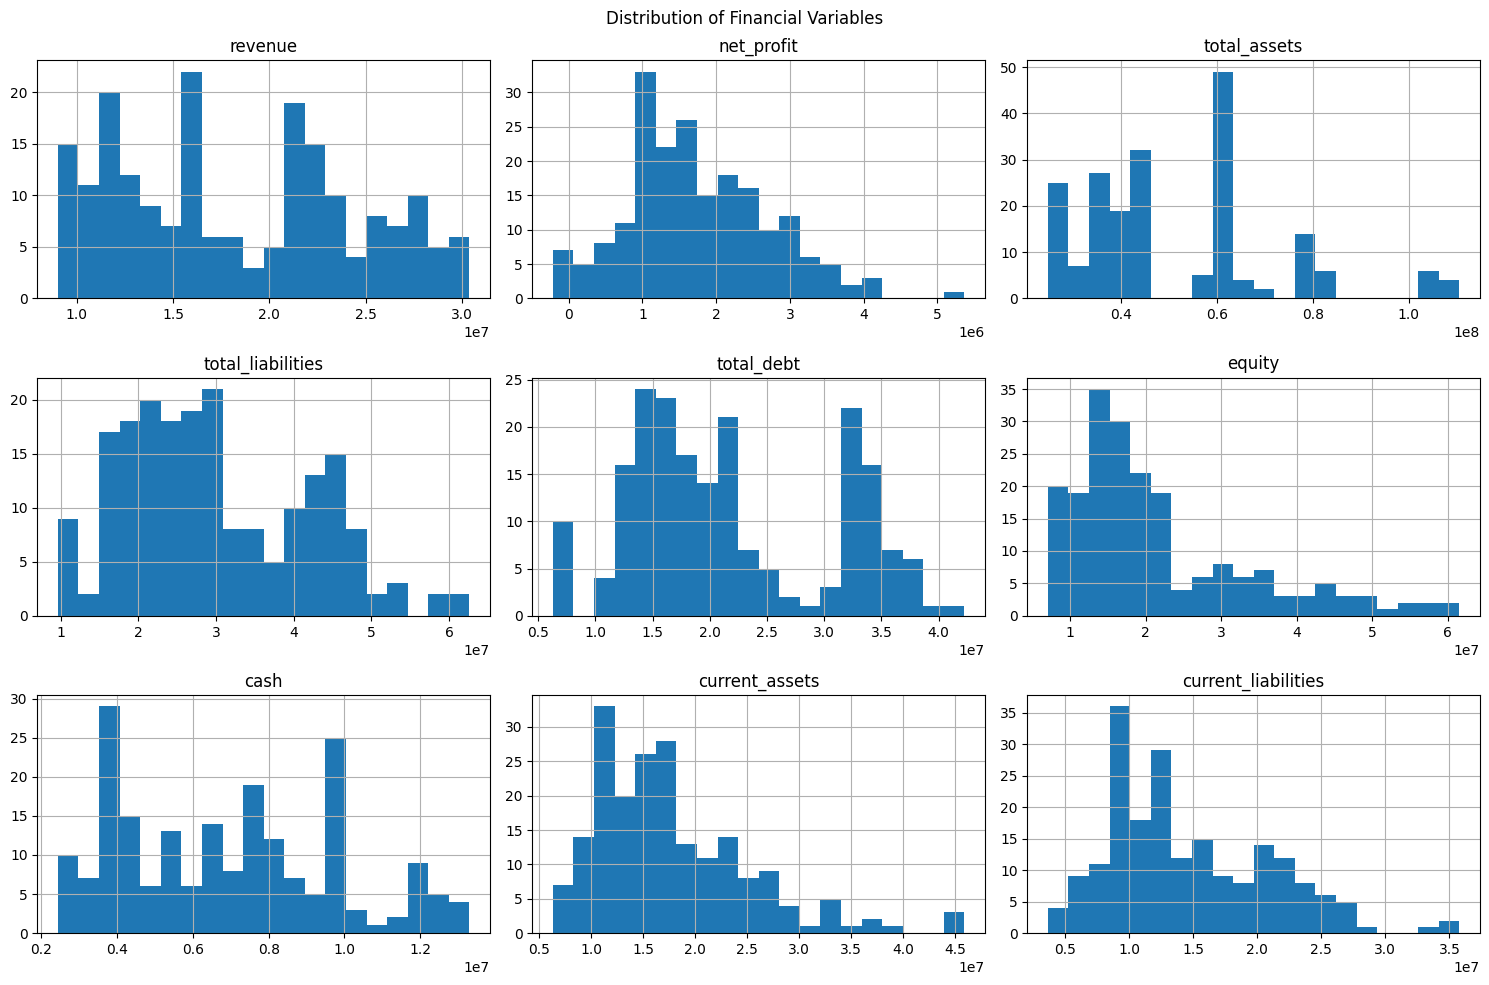

In [31]:

fd[financial_cols].hist(figsize=(15, 10), bins=20)

plt.suptitle("Distribution of Financial Variables")
plt.tight_layout()
plt.show()

In [32]:
#Safe Division Function
def safe_divide(numerator, denominator):
    return np.where(
        denominator != 0,
        numerator / denominator,
        np.nan
    )

In [33]:
# Financial Ratio Features

fd["profit_margin"] = safe_divide(
    fd["net_profit"],
    fd["revenue"]
)

fd["debt_ratio"] = safe_divide(
    fd["total_debt"],
    fd["total_assets"]
)

fd["liability_ratio"] = safe_divide(
    fd["total_liabilities"],
    fd["total_assets"]
)

fd["debt_to_equity"] = safe_divide(
    fd["total_debt"],
    fd["equity"]
)

fd["current_ratio"] = safe_divide(
    fd["current_assets"],
    fd["current_liabilities"]
)

fd["cash_ratio"] = safe_divide(
    fd["cash"],
    fd["current_liabilities"]
)

ratio_cols = [
    "profit_margin",
    "debt_ratio",
    "liability_ratio",
    "debt_to_equity",
    "current_ratio",
    "cash_ratio"
]

fd[ratio_cols] = fd[ratio_cols].replace([np.inf, -np.inf], np.nan)

display(fd[["company_id", "period"] + ratio_cols].head())

,company_id,period,profit_margin,debt_ratio,liability_ratio,debt_to_equity,current_ratio,cash_ratio
0,1,2024Q1,0.072278,0.503925,0.602324,1.267176,1.672817,0.429651
1,1,2024Q2,0.069390,0.509744,0.612196,1.314437,1.077506,0.416503
2,1,2024Q3,0.088223,0.526230,0.607687,1.341352,1.073527,0.481539
3,1,2024Q4,0.097036,0.525349,0.643920,1.475367,0.813324,0.302168
4,1,2025Q1,0.088822,0.544396,0.659420,1.598442,1.301257,0.374469


,count,mean,std,min,25%,50%,75%,max
profit_margin,200.0,0.097026,0.040985,-0.009680,0.073450,0.098708,0.120356,0.176684
debt_ratio,200.0,0.425884,0.099784,0.250602,0.345262,0.426100,0.524471,0.617769
liability_ratio,200.0,0.589443,0.111354,0.361058,0.498032,0.585304,0.678676,0.862543
debt_to_equity,200.0,1.200490,0.649506,0.402500,0.695638,0.990109,1.597324,4.494263
current_ratio,200.0,1.287799,0.422364,0.608295,0.972415,1.223091,1.527877,2.744422
cash_ratio,200.0,0.505661,0.165343,0.199983,0.388684,0.486814,0.611165,0.966399


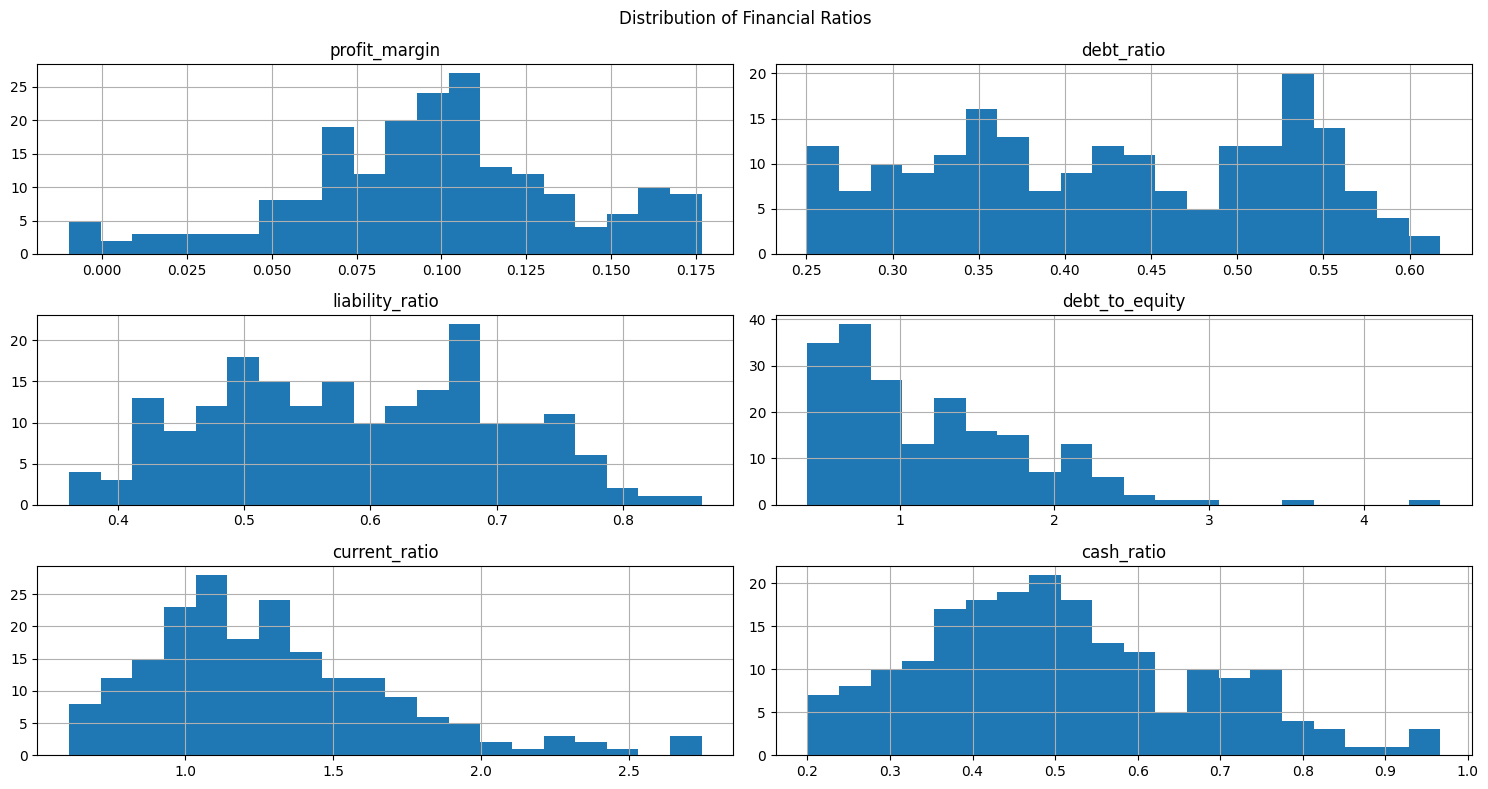

In [34]:
#Financial Ratios Summary

display(fd[ratio_cols].describe().T)

fd[ratio_cols].hist(figsize=(15, 8), bins=20)

plt.suptitle("Distribution of Financial Ratios")
plt.tight_layout()
plt.show()

In [35]:
#Growth and Trend Feature
fd["revenue_growth"] = (
    fd.groupby("company_id")["revenue"]
    .pct_change(fill_method=None)
)

fd["profit_growth"] = (
    fd.groupby("company_id")["net_profit"]
    .pct_change(fill_method=None)
)

fd["debt_growth"] = (
    fd.groupby("company_id")["total_debt"]
    .pct_change(fill_method=None)
)

fd["cash_growth"] = (
    fd.groupby("company_id")["cash"]
    .pct_change(fill_method=None)
)

fd["equity_growth"] = (
    fd.groupby("company_id")["equity"]
    .pct_change(fill_method=None)
)

growth_cols = [
    "revenue_growth",
    "profit_growth",
    "debt_growth",
    "cash_growth",
    "equity_growth"
]

fd[growth_cols] = fd[growth_cols].replace([np.inf, -np.inf], np.nan)

display(fd[["company_id", "period"] + growth_cols].head(12))

,company_id,period,revenue_growth,profit_growth,debt_growth,cash_growth,equity_growth
0,1,2024Q1,NaN,NaN,NaN,NaN,NaN
1,1,2024Q2,0.004534,-0.035604,-0.015357,0.017134,-0.050761
2,1,2024Q3,0.039279,0.321358,0.047960,0.008508,0.026932
3,1,2024Q4,-0.004886,0.094515,0.006746,0.004528,-0.084701
4,1,2025Q1,0.002111,-0.082719,0.040385,0.035565,-0.039722
5,1,2025Q2,0.005486,-0.106556,-0.009172,0.031753,-0.070538
6,1,2025Q3,0.000199,-0.152044,0.028154,0.011483,0.244270
7,1,2025Q4,-0.007755,-0.002172,-0.023197,0.035343,-0.173642
8,1,2026Q1,0.000138,0.264918,0.040834,0.032713,-0.018876
9,1,2026Q2,-0.014372,-0.375773,0.029432,0.014862,-0.254767


In [36]:
# Growth Features Summary
display(fd[growth_cols].describe().T)


,count,mean,std,min,25%,50%,75%,max
revenue_growth,180.0,0.007847,0.027446,-0.088008,-0.008615,0.007266,0.025554,0.081890
profit_growth,180.0,-0.100071,1.789379,-13.813572,-0.241576,-0.018307,0.206745,14.098587
debt_growth,180.0,0.013209,0.023284,-0.038812,-0.003015,0.011892,0.028223,0.085169
cash_growth,180.0,0.008526,0.025072,-0.059076,-0.009648,0.009226,0.027662,0.071632
equity_growth,180.0,0.009309,0.187048,-0.517626,-0.108772,0.004215,0.122065,0.532093


In [37]:
# Warning Flags

fd["profitability_warning"] = (
    fd["profit_margin"] < 0
).astype(int)

fd["liquidity_warning"] = (
    fd["current_ratio"] < 1
).astype(int)

fd["leverage_warning"] = (
    fd["debt_to_equity"] > 2
).astype(int)

fd["debt_growth_warning"] = (
    fd["debt_growth"] > 0
).astype(int)

fd["profit_decline_warning"] = (
    fd["profit_growth"] < 0
).astype(int)

fd["cash_decline_warning"] = (
    fd["cash_growth"] < 0
).astype(int)

fd["equity_decline_warning"] = (
    fd["equity_growth"] < 0
).astype(int)

warning_cols = [
    "profitability_warning",
    "liquidity_warning",
    "leverage_warning",
    "debt_growth_warning",
    "profit_decline_warning",
    "cash_decline_warning",
    "equity_decline_warning"
]

fd["negative_financial_signals"] = fd[warning_cols].sum(axis=1)

display(fd[["company_id", "period"] + warning_cols + ["negative_financial_signals"]].head(12))

,company_id,period,profitability_warning,liquidity_warning,leverage_warning,debt_growth_warning,profit_decline_warning,cash_decline_warning,equity_decline_warning,negative_financial_signals
0,1,2024Q1,0,0,0,0,0,0,0,0
1,1,2024Q2,0,0,0,0,1,0,1,2
2,1,2024Q3,0,0,0,1,0,0,0,1
3,1,2024Q4,0,1,0,1,0,0,1,3
4,1,2025Q1,0,0,0,1,1,0,1,3
5,1,2025Q2,0,1,0,0,1,0,1,3
6,1,2025Q3,0,0,0,1,1,0,0,2
7,1,2025Q4,0,0,0,0,1,0,1,2
8,1,2026Q1,0,0,0,1,0,0,1,2
9,1,2026Q2,0,0,1,1,1,0,1,4


In [38]:
# Risk Scoring Functions
def score_profit_margin(x):
    if pd.isna(x):
        return np.nan
    elif x >= 0.15:
        return 0
    elif x >= 0.10:
        return 25
    elif x >= 0.05:
        return 50
    elif x >= 0:
        return 75
    else:
        return 100


def score_profit_growth(x):
    if pd.isna(x):
        return np.nan
    elif x >= 0:
        return 0
    elif x >= -0.10:
        return 25
    elif x >= -0.25:
        return 50
    elif x >= -0.50:
        return 75
    else:
        return 100


def score_revenue_growth(x):
    if pd.isna(x):
        return np.nan
    elif x >= 0:
        return 0
    elif x >= -0.10:
        return 25
    elif x >= -0.20:
        return 50
    elif x >= -0.40:
        return 75
    else:
        return 100


def score_debt_growth(x):
    if pd.isna(x):
        return np.nan
    elif x <= 0:
        return 0
    elif x <= 0.10:
        return 25
    elif x <= 0.25:
        return 50
    elif x <= 0.50:
        return 75
    else:
        return 100


def score_current_ratio(x):
    if pd.isna(x):
        return np.nan
    elif x >= 2:
        return 0
    elif x >= 1.5:
        return 25
    elif x >= 1:
        return 50
    elif x >= 0.75:
        return 75
    else:
        return 100


def score_debt_to_equity(x):
    if pd.isna(x):
        return np.nan
    elif x < 0:
        return 100
    elif x <= 1:
        return 0
    elif x <= 2:
        return 25
    elif x <= 3:
        return 50
    elif x <= 5:
        return 75
    else:
        return 100


def score_cash_growth(x):
    if pd.isna(x):
        return np.nan
    elif x >= 0:
        return 0
    elif x >= -0.10:
        return 25
    elif x >= -0.25:
        return 50
    elif x >= -0.50:
        return 75
    else:
        return 100


def score_equity_growth(x):
    if pd.isna(x):
        return np.nan
    elif x >= 0:
        return 0
    elif x >= -0.10:
        return 25
    elif x >= -0.25:
        return 50
    elif x >= -0.50:
        return 75
    else:
        return 100

In [39]:
#Apply Risk Scores
fd["profit_margin_risk"] = fd["profit_margin"].apply(score_profit_margin)

fd["profit_growth_risk"] = fd["profit_growth"].apply(score_profit_growth)

fd["revenue_risk"] = fd["revenue_growth"].apply(score_revenue_growth)

fd["debt_growth_risk"] = fd["debt_growth"].apply(score_debt_growth)

fd["liquidity_risk"] = fd["current_ratio"].apply(score_current_ratio)

fd["leverage_risk"] = fd["debt_to_equity"].apply(score_debt_to_equity)

fd["cash_risk"] = fd["cash_growth"].apply(score_cash_growth)

fd["equity_risk"] = fd["equity_growth"].apply(score_equity_growth)

fd["profitability_risk"] = fd[
    ["profit_margin_risk", "profit_growth_risk"]
].mean(axis=1)

risk_score_cols_preview = [
    "company_id",
    "period",
    "profitability_risk",
    "liquidity_risk",
    "leverage_risk",
    "debt_growth_risk",
    "revenue_risk",
    "cash_risk",
    "equity_risk"
]

display(fd[risk_score_cols_preview].head(12))

,company_id,period,profitability_risk,liquidity_risk,leverage_risk,debt_growth_risk,revenue_risk,cash_risk,equity_risk
0,1,2024Q1,50.0,25,25,NaN,NaN,NaN,NaN
1,1,2024Q2,37.5,50,25,0.0,0.0,0.0,25.0
2,1,2024Q3,25.0,50,25,25.0,0.0,0.0,0.0
3,1,2024Q4,25.0,75,25,25.0,25.0,0.0,25.0
4,1,2025Q1,37.5,50,25,25.0,0.0,0.0,25.0
5,1,2025Q2,50.0,75,25,0.0,0.0,0.0,25.0
6,1,2025Q3,50.0,50,25,25.0,0.0,0.0,0.0
7,1,2025Q4,37.5,50,25,0.0,25.0,0.0,50.0
8,1,2026Q1,25.0,50,25,25.0,0.0,0.0,25.0
9,1,2026Q2,62.5,50,50,25.0,25.0,0.0,75.0


In [40]:
#Financial Risk Score

weights = {
    "profitability_risk": 0.25,
    "liquidity_risk": 0.20,
    "leverage_risk": 0.20,
    "debt_growth_risk": 0.15,
    "revenue_risk": 0.10,
    "cash_risk": 0.05,
    "equity_risk": 0.05
}

risk_component_cols = list(weights.keys())
weight_series = pd.Series(weights)

weighted_sum = fd[risk_component_cols].mul(
    weight_series,
    axis=1
).sum(axis=1, skipna=True)

available_weights = fd[risk_component_cols].notna().mul(
    weight_series,
    axis=1
).sum(axis=1)

fd["financial_risk_score"] = np.where(
    available_weights > 0,
    weighted_sum / available_weights,
    np.nan
)

fd["financial_risk_score"] = fd["financial_risk_score"].round(2)

display(fd[["company_id", "period", "financial_risk_score"] + risk_component_cols].head(12))

,company_id,period,financial_risk_score,profitability_risk,liquidity_risk,leverage_risk,debt_growth_risk,revenue_risk,cash_risk,equity_risk
0,1,2024Q1,34.62,50.0,25,25,NaN,NaN,NaN,NaN
1,1,2024Q2,25.62,37.5,50,25,0.0,0.0,0.0,25.0
2,1,2024Q3,25.00,25.0,50,25,25.0,0.0,0.0,0.0
3,1,2024Q4,33.75,25.0,75,25,25.0,25.0,0.0,25.0
4,1,2025Q1,29.38,37.5,50,25,25.0,0.0,0.0,25.0
5,1,2025Q2,33.75,50.0,75,25,0.0,0.0,0.0,25.0
6,1,2025Q3,31.25,50.0,50,25,25.0,0.0,0.0,0.0
7,1,2025Q4,29.38,37.5,50,25,0.0,25.0,0.0,50.0
8,1,2026Q1,26.25,25.0,50,25,25.0,0.0,0.0,25.0
9,1,2026Q2,45.62,62.5,50,50,25.0,25.0,0.0,75.0


In [41]:
# Financial Risk Level

def get_risk_level(score):
    if pd.isna(score):
        return "Unknown"
    elif score < 40:
        return "Low"
    elif score < 60:
        return "Medium"
    elif score < 80:
        return "High"
    else:
        return "Critical"


fd["financial_risk_level"] = fd["financial_risk_score"].apply(get_risk_level)

display(fd[["company_id", "period", "financial_risk_score", "financial_risk_level"]].head(12))

,company_id,period,financial_risk_score,financial_risk_level
0,1,2024Q1,34.62,Low
1,1,2024Q2,25.62,Low
2,1,2024Q3,25.00,Low
3,1,2024Q4,33.75,Low
4,1,2025Q1,29.38,Low
5,1,2025Q2,33.75,Low
6,1,2025Q3,31.25,Low
7,1,2025Q4,29.38,Low
8,1,2026Q1,26.25,Low
9,1,2026Q2,45.62,Medium


In [42]:
#Risk Trend

fd["risk_score_change"] = (
    fd.groupby("company_id")["financial_risk_score"]
    .diff()
)

fd["risk_trend"] = np.select(
    [
        fd["risk_score_change"] >= 15,
        fd["risk_score_change"] >= 5,
        fd["risk_score_change"] <= -5
    ],
    [
        "Rapid Deterioration",
        "Deteriorating",
        "Improving"
    ],
    default="Stable"
)

display(fd[["company_id", "period", "financial_risk_score", "risk_score_change", "risk_trend"]].head(12))

,company_id,period,financial_risk_score,risk_score_change,risk_trend
0,1,2024Q1,34.62,NaN,Stable
1,1,2024Q2,25.62,-9.00,Improving
2,1,2024Q3,25.00,-0.62,Stable
3,1,2024Q4,33.75,8.75,Deteriorating
4,1,2025Q1,29.38,-4.37,Stable
5,1,2025Q2,33.75,4.37,Stable
6,1,2025Q3,31.25,-2.50,Stable
7,1,2025Q4,29.38,-1.87,Stable
8,1,2026Q1,26.25,-3.13,Stable
9,1,2026Q2,45.62,19.37,Rapid Deterioration


In [43]:
#Main Financial Risk Factor

factor_names = {
    "profitability_risk": "Profitability",
    "liquidity_risk": "Liquidity",
    "leverage_risk": "Leverage",
    "debt_growth_risk": "Debt Growth",
    "revenue_risk": "Revenue Decline",
    "cash_risk": "Cash Decline",
    "equity_risk": "Equity Decline"
}

fd["main_financial_risk_factor"] = (
    fd[risk_component_cols]
    .idxmax(axis=1)
    .map(factor_names)
)

display(fd[["company_id", "period", "financial_risk_score", "main_financial_risk_factor"]].head(12))

,company_id,period,financial_risk_score,main_financial_risk_factor
0,1,2024Q1,34.62,Profitability
1,1,2024Q2,25.62,Liquidity
2,1,2024Q3,25.00,Liquidity
3,1,2024Q4,33.75,Liquidity
4,1,2025Q1,29.38,Liquidity
5,1,2025Q2,33.75,Liquidity
6,1,2025Q3,31.25,Profitability
7,1,2025Q4,29.38,Liquidity
8,1,2026Q1,26.25,Liquidity
9,1,2026Q2,45.62,Equity Decline


In [44]:
#Financial Risk Explanation

def generate_financial_explanation(row):
    reasons = []

    if row["profitability_risk"] >= 60:
        reasons.append("weak profitability or declining profit")

    if row["liquidity_risk"] >= 60:
        reasons.append("low liquidity position")

    if row["leverage_risk"] >= 60:
        reasons.append("high leverage level")

    if row["debt_growth_risk"] >= 60:
        reasons.append("rapid debt growth")

    if row["revenue_risk"] >= 60:
        reasons.append("declining revenue")

    if row["cash_risk"] >= 60:
        reasons.append("declining cash position")

    if row["equity_risk"] >= 60:
        reasons.append("declining equity")

    if len(reasons) == 0:
        return "No major financial risk drivers detected."

    return "Main financial risk drivers: " + ", ".join(reasons) + "."


fd["financial_risk_explanation"] = fd.apply(
    generate_financial_explanation,
    axis=1
)

display(fd[[
    "company_id",
    "period",
    "financial_risk_score",
    "financial_risk_level",
    "main_financial_risk_factor",
    "financial_risk_explanation"
]].head(12))

,company_id,period,financial_risk_score,financial_risk_level,main_financial_risk_factor,financial_risk_explanation
0,1,2024Q1,34.62,Low,Profitability,No major financial risk drivers detected.
1,1,2024Q2,25.62,Low,Liquidity,No major financial risk drivers detected.
2,1,2024Q3,25.00,Low,Liquidity,No major financial risk drivers detected.
3,1,2024Q4,33.75,Low,Liquidity,Main financial risk drivers: low liquidity pos...
4,1,2025Q1,29.38,Low,Liquidity,No major financial risk drivers detected.
5,1,2025Q2,33.75,Low,Liquidity,Main financial risk drivers: low liquidity pos...
6,1,2025Q3,31.25,Low,Profitability,No major financial risk drivers detected.
7,1,2025Q4,29.38,Low,Liquidity,No major financial risk drivers detected.
8,1,2026Q1,26.25,Low,Liquidity,No major financial risk drivers detected.
9,1,2026Q2,45.62,Medium,Equity Decline,Main financial risk drivers: weak profitabilit...


In [45]:
# Financial Assessment Output

financial_assessment = fd[
    [
        "id",
        "company_id",
        "period",
        "revenue",
        "net_profit",
        "total_assets",
        "total_liabilities",
        "total_debt",
        "equity",
        "cash",
        "current_assets",
        "current_liabilities",
        "profit_margin",
        "debt_ratio",
        "liability_ratio",
        "debt_to_equity",
        "current_ratio",
        "cash_ratio",
        "revenue_growth",
        "profit_growth",
        "debt_growth",
        "cash_growth",
        "equity_growth",
        "profitability_warning",
        "liquidity_warning",
        "leverage_warning",
        "debt_growth_warning",
        "profit_decline_warning",
        "cash_decline_warning",
        "equity_decline_warning",
        "negative_financial_signals",
        "profitability_risk",
        "liquidity_risk",
        "leverage_risk",
        "debt_growth_risk",
        "revenue_risk",
        "cash_risk",
        "equity_risk",
        "financial_risk_score",
        "financial_risk_level",
        "risk_score_change",
        "risk_trend",
        "main_financial_risk_factor",
        "financial_risk_explanation"
    ]
].copy()

display(financial_assessment.head())

,id,company_id,period,revenue,net_profit,total_assets,total_liabilities,total_debt,equity,cash,...,debt_growth_risk,revenue_risk,cash_risk,equity_risk,financial_risk_score,financial_risk_level,risk_score_change,risk_trend,main_financial_risk_factor,financial_risk_explanation
0,1,1,2024Q1,11794216.19,852460.59,39876783.98,24018740.84,20094923.92,15858043.14,4472316.69,...,NaN,NaN,NaN,NaN,34.62,Low,NaN,Stable,Profitability,No major financial risk drivers detected.
1,2,1,2024Q2,11847692.69,822109.59,38816164.07,23763085.46,19786316.74,15053078.61,4548943.66,...,0.0,0.0,0.0,25.0,25.62,Low,-9.00,Improving,Liquidity,No major financial risk drivers detected.
2,3,1,2024Q3,12313058.08,1086301.02,39403431.60,23944945.70,20735269.60,15458485.90,4587645.51,...,25.0,0.0,0.0,0.0,25.00,Low,-0.62,Stable,Liquidity,No major financial risk drivers detected.
3,4,1,2024Q4,12252894.47,1188972.75,39735785.44,25586654.36,20875158.22,14149131.08,4608420.10,...,25.0,25.0,0.0,25.0,33.75,Low,8.75,Deteriorating,Liquidity,Main financial risk drivers: low liquidity pos...
4,5,1,2025Q1,12278766.00,1090621.88,39894077.77,26306972.07,21718194.35,13587105.70,4772316.70,...,25.0,0.0,0.0,25.0,29.38,Low,-4.37,Stable,Liquidity,No major financial risk drivers detected.


In [46]:
final_column_order = [
    "id",
    "company_id",
    "period",
    "financial_risk_score",
    "financial_risk_level",
    "risk_score_change",
    "risk_trend",
    "main_financial_risk_factor",
    "financial_risk_explanation",
    "negative_financial_signals",
    "profitability_risk",
    "liquidity_risk",
    "leverage_risk",
    "debt_growth_risk",
    "revenue_risk",
    "cash_risk",
    "equity_risk",
    "revenue",
    "net_profit",
    "total_assets",
    "total_liabilities",
    "total_debt",
    "equity",
    "cash",
    "current_assets",
    "current_liabilities",
    "profit_margin",
    "debt_ratio",
    "liability_ratio",
    "debt_to_equity",
    "current_ratio",
    "cash_ratio",
    "revenue_growth",
    "profit_growth",
    "debt_growth",
    "cash_growth",
    "equity_growth",
    "profitability_warning",
    "liquidity_warning",
    "leverage_warning",
    "debt_growth_warning",
    "profit_decline_warning",
    "cash_decline_warning",
    "equity_decline_warning"
]

financial_assessment = financial_assessment[final_column_order]

display(financial_assessment.head())

,id,company_id,period,financial_risk_score,financial_risk_level,risk_score_change,risk_trend,main_financial_risk_factor,financial_risk_explanation,negative_financial_signals,...,debt_growth,cash_growth,equity_growth,profitability_warning,liquidity_warning,leverage_warning,debt_growth_warning,profit_decline_warning,cash_decline_warning,equity_decline_warning
0,1,1,2024Q1,34.62,Low,NaN,Stable,Profitability,No major financial risk drivers detected.,0,...,NaN,NaN,NaN,0,0,0,0,0,0,0
1,2,1,2024Q2,25.62,Low,-9.00,Improving,Liquidity,No major financial risk drivers detected.,2,...,-0.015357,0.017134,-0.050761,0,0,0,0,1,0,1
2,3,1,2024Q3,25.00,Low,-0.62,Stable,Liquidity,No major financial risk drivers detected.,1,...,0.047960,0.008508,0.026932,0,0,0,1,0,0,0
3,4,1,2024Q4,33.75,Low,8.75,Deteriorating,Liquidity,Main financial risk drivers: low liquidity pos...,3,...,0.006746,0.004528,-0.084701,0,1,0,1,0,0,1
4,5,1,2025Q1,29.38,Low,-4.37,Stable,Liquidity,No major financial risk drivers detected.,3,...,0.040385,0.035565,-0.039722,0,0,0,1,1,0,1


In [47]:
#Latest Financial Assessment Per Company

latest_financial_assessment = (
    financial_assessment
    .sort_values(["company_id", "period"])
    .groupby("company_id")
    .tail(1)
    .reset_index(drop=True)
)

display(latest_financial_assessment.head())

,id,company_id,period,financial_risk_score,financial_risk_level,risk_score_change,risk_trend,main_financial_risk_factor,financial_risk_explanation,negative_financial_signals,...,debt_growth,cash_growth,equity_growth,profitability_warning,liquidity_warning,leverage_warning,debt_growth_warning,profit_decline_warning,cash_decline_warning,equity_decline_warning
0,10,1,2026Q2,45.62,Medium,19.37,Rapid Deterioration,Equity Decline,Main financial risk drivers: weak profitabilit...,4,...,0.029432,0.014862,-0.254767,0,0,1,1,1,0,1
1,20,2,2026Q2,42.50,Medium,11.25,Deteriorating,Liquidity,Main financial risk drivers: low liquidity pos...,3,...,0.000197,0.004983,0.049396,0,1,1,1,0,0,0
2,30,3,2026Q2,48.75,Medium,8.13,Deteriorating,Liquidity,Main financial risk drivers: low liquidity pos...,5,...,0.008798,0.014887,-0.217739,0,1,1,1,1,0,1
3,40,4,2026Q2,33.75,Low,12.50,Deteriorating,Liquidity,Main financial risk drivers: low liquidity pos...,5,...,0.006966,-0.014812,-0.317429,0,1,1,1,0,1,1
4,50,5,2026Q2,16.88,Low,7.50,Deteriorating,Liquidity,No major financial risk drivers detected.,3,...,0.005899,-0.015286,-0.085325,0,0,0,1,0,1,1


In [48]:
# Risk Level Distribution

print("Risk Level Distribution - All Periods:")
print(financial_assessment["financial_risk_level"].value_counts())

print("\nRisk Level Distribution - Latest Period:")
print(latest_financial_assessment["financial_risk_level"].value_counts())

Risk Level Distribution - All Periods:
financial_risk_level
Low       169
Medium     30
High        1
Name: count, dtype: int64

Risk Level Distribution - Latest Period:
financial_risk_level
Low       15
Medium     4
High       1
Name: count, dtype: int64


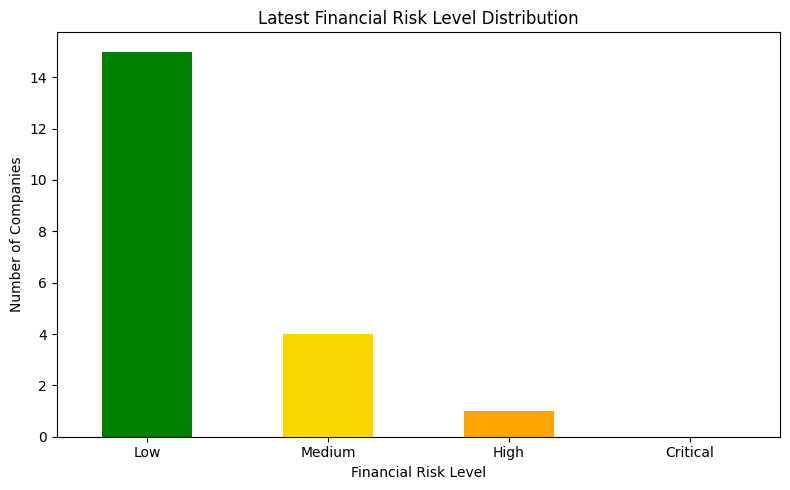

In [49]:
# Plot Latest Risk Distribution

risk_order = ["Low", "Medium", "High", "Critical"]

latest_counts = (
    latest_financial_assessment["financial_risk_level"]
    .value_counts()
    .reindex(risk_order, fill_value=0)
)

latest_counts.plot(
    kind="bar",
    figsize=(8, 5),
    color=["green", "gold", "orange", "red"]
)

plt.title("Latest Financial Risk Level Distribution")
plt.xlabel("Financial Risk Level")
plt.ylabel("Number of Companies")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [50]:
#Top High-Risk Companies

high_risk_companies = latest_financial_assessment[
    latest_financial_assessment["financial_risk_level"].isin(["High", "Critical"])
].sort_values("financial_risk_score", ascending=False)

display(high_risk_companies[
    [
        "company_id",
        "period",
        "financial_risk_score",
        "financial_risk_level",
        "risk_trend",
        "main_financial_risk_factor",
        "financial_risk_explanation"
    ]
].head(10))

,company_id,period,financial_risk_score,financial_risk_level,risk_trend,main_financial_risk_factor,financial_risk_explanation
18,19,2026Q2,68.12,High,Deteriorating,Liquidity,Main financial risk drivers: weak profitabilit...


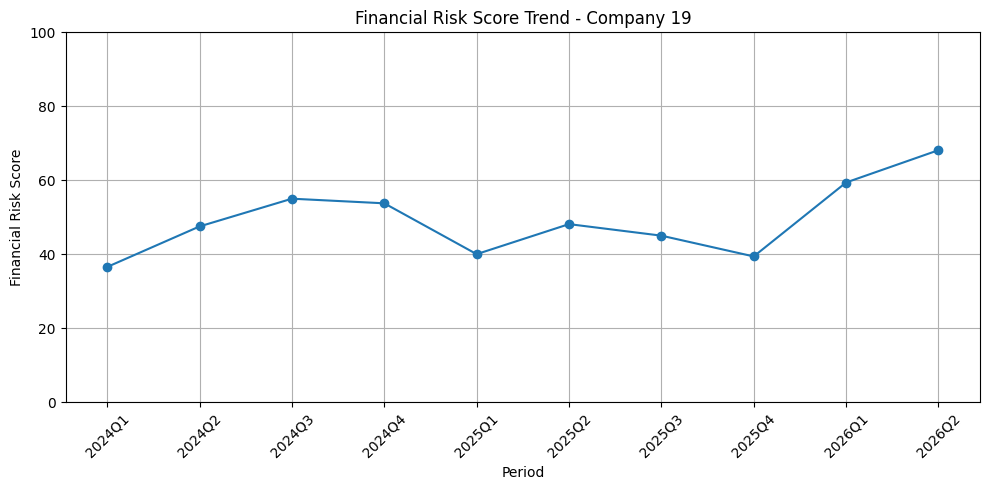

,company_id,period,financial_risk_score,financial_risk_level,risk_trend,main_financial_risk_factor
180,19,2024Q1,36.54,Low,Stable,Profitability
181,19,2024Q2,47.50,Medium,Deteriorating,Profitability
182,19,2024Q3,55.00,Medium,Deteriorating,Profitability
183,19,2024Q4,53.75,Medium,Stable,Profitability
184,19,2025Q1,40.00,Medium,Improving,Liquidity
185,19,2025Q2,48.12,Medium,Deteriorating,Profitability
186,19,2025Q3,45.00,Medium,Stable,Profitability
187,19,2025Q4,39.38,Low,Improving,Liquidity
188,19,2026Q1,59.38,Medium,Rapid Deterioration,Liquidity
189,19,2026Q2,68.12,High,Deteriorating,Liquidity


In [51]:
# Financial Risk Trend Example

example_company_id = latest_financial_assessment.sort_values(
    "financial_risk_score",
    ascending=False
)["company_id"].iloc[0]

company_trend = financial_assessment[
    financial_assessment["company_id"] == example_company_id
].sort_values("period")

plt.figure(figsize=(10, 5))

plt.plot(
    company_trend["period"].astype(str),
    company_trend["financial_risk_score"],
    marker="o"
)

plt.title(f"Financial Risk Score Trend - Company {example_company_id}")
plt.xlabel("Period")
plt.ylabel("Financial Risk Score")
plt.ylim(0, 100)
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

display(company_trend[
    [
        "company_id",
        "period",
        "financial_risk_score",
        "financial_risk_level",
        "risk_trend",
        "main_financial_risk_factor"
    ]
])

In [52]:
# Output for Overall Risk Integration

financial_output_for_overall = latest_financial_assessment[
    [
        "company_id",
        "period",
        "financial_risk_score",
        "financial_risk_level",
        "risk_trend",
        "main_financial_risk_factor",
        "financial_risk_explanation"
    ]
].copy()

financial_output_for_overall = financial_output_for_overall.rename(
    columns={
        "financial_risk_score": "financial_score",
        "financial_risk_level": "financial_level"
    }
)

display(financial_output_for_overall.head())

,company_id,period,financial_score,financial_level,risk_trend,main_financial_risk_factor,financial_risk_explanation
0,1,2026Q2,45.62,Medium,Rapid Deterioration,Equity Decline,Main financial risk drivers: weak profitabilit...
1,2,2026Q2,42.50,Medium,Deteriorating,Liquidity,Main financial risk drivers: low liquidity pos...
2,3,2026Q2,48.75,Medium,Deteriorating,Liquidity,Main financial risk drivers: low liquidity pos...
3,4,2026Q2,33.75,Low,Deteriorating,Liquidity,Main financial risk drivers: low liquidity pos...
4,5,2026Q2,16.88,Low,Deteriorating,Liquidity,No major financial risk drivers detected.


In [53]:
# Export Financial Risk Outputs

financial_assessment.to_csv(
    "financial_risk_assessment_all_periods.csv",
    index=False
)

latest_financial_assessment.to_csv(
    "financial_risk_assessment_latest.csv",
    index=False
)

financial_output_for_overall.to_csv(
    "financial_output_for_overall.csv",
    index=False
)

# 4. Overall Risk Score

This section combines the Complaints Risk and Financial Risk scores
to generate an overall company risk score and early warning level.

In [54]:
# Merge Complaints Risk and Financial Risk

overall_risk = complaint_risk_output.merge(
    financial_output_for_overall,
    on="company_id",
    how="outer"
)

overall_risk.head()

,company_id,complaint_risk_score,complaint_risk_level,risk_drivers,complaint_early_warning,period,financial_score,financial_level,risk_trend,main_financial_risk_factor,financial_risk_explanation
0,1,18.91,Low,"[High complaint volume, High severity complain...",No high-risk complaint warning.,2026Q2,45.62,Medium,Rapid Deterioration,Equity Decline,Main financial risk drivers: weak profitabilit...
1,2,68.31,Medium,"[High negative sentiment, High number of open ...",No high-risk complaint warning.,2026Q2,42.50,Medium,Deteriorating,Liquidity,Main financial risk drivers: low liquidity pos...
2,3,7.10,Low,"[High number of open complaints, High complain...",No high-risk complaint warning.,2026Q2,48.75,Medium,Deteriorating,Liquidity,Main financial risk drivers: low liquidity pos...
3,4,36.65,Low,"[High severity complaints, Fraud-related compl...",No high-risk complaint warning.,2026Q2,33.75,Low,Deteriorating,Liquidity,Main financial risk drivers: low liquidity pos...
4,5,46.11,Medium,"[High negative sentiment, High severity compla...",No high-risk complaint warning.,2026Q2,16.88,Low,Deteriorating,Liquidity,No major financial risk drivers detected.


In [55]:
# Calculate Overall Risk Score

overall_risk["overall_risk_score"] = (
    0.50 * overall_risk["complaint_risk_score"]
    + 0.50 * overall_risk["financial_score"]
).round(2)

overall_risk[
    [
        "company_id",
        "complaint_risk_score",
        "financial_score",
        "overall_risk_score"
    ]
].sort_values(
    "overall_risk_score",
    ascending=False
).head(10)

,company_id,complaint_risk_score,financial_score,overall_risk_score
18,19,61.06,68.12,64.59
1,2,68.31,42.50,55.40
12,13,73.10,25.62,49.36
16,17,52.83,45.62,49.22
14,15,55.25,35.62,45.44
11,12,69.29,20.00,44.64
19,20,62.73,25.00,43.86
9,10,38.55,39.38,38.97
13,14,50.49,26.88,38.68
6,7,58.24,16.88,37.56


In [56]:
# Determine Overall Risk Level

def get_overall_risk_level(score):
    if score >= 85:
        return "Critical"
    elif score >= 70:
        return "High"
    elif score >= 40:
        return "Medium"
    else:
        return "Low"


overall_risk["overall_risk_level"] = (
    overall_risk["overall_risk_score"]
    .apply(get_overall_risk_level)
)

overall_risk[
    [
        "company_id",
        "overall_risk_score",
        "overall_risk_level"
    ]
].sort_values(
    "overall_risk_score",
    ascending=False
)

,company_id,overall_risk_score,overall_risk_level
18,19,64.59,Medium
1,2,55.40,Medium
12,13,49.36,Medium
16,17,49.22,Medium
14,15,45.44,Medium
11,12,44.64,Medium
19,20,43.86,Medium
9,10,38.97,Low
13,14,38.68,Low
6,7,37.56,Low


In [57]:
# Generate Early Warning

def generate_early_warning(row):
    warnings = []

    if row["overall_risk_level"] in ["High", "Critical"]:
        warnings.append(
            f"Overall risk is {row['overall_risk_level']} "
            f"(score: {row['overall_risk_score']:.2f})"
        )

    if row["complaint_risk_level"] in ["High", "Critical"]:
        warnings.append(
            f"High complaint risk ({row['complaint_risk_score']:.2f})"
        )

    if row["financial_level"] in ["High", "Critical"]:
        warnings.append(
            f"High financial risk ({row['financial_score']:.2f})"
        )

    if warnings:
        return "EARLY WARNING: " + ". ".join(warnings) + "."
    
    return "No Early Warning"


overall_risk["early_warning"] = overall_risk.apply(
    generate_early_warning,
    axis=1
)

overall_risk[
    [
        "company_id",
        "overall_risk_score",
        "overall_risk_level",
        "early_warning"
    ]
].sort_values(
    "overall_risk_score",
    ascending=False
)

,company_id,overall_risk_score,overall_risk_level,early_warning
18,19,64.59,Medium,EARLY WARNING: High financial risk (68.12).
1,2,55.40,Medium,No Early Warning
12,13,49.36,Medium,EARLY WARNING: High complaint risk (73.10).
16,17,49.22,Medium,No Early Warning
14,15,45.44,Medium,No Early Warning
11,12,44.64,Medium,No Early Warning
19,20,43.86,Medium,No Early Warning
9,10,38.97,Low,No Early Warning
13,14,38.68,Low,No Early Warning
6,7,37.56,Low,No Early Warning


In [58]:
# Final Overall Risk Output

final_risk_output = overall_risk[
    [
        "company_id",
        "complaint_risk_score",
        "complaint_risk_level",
        "financial_score",
        "financial_level",
        "overall_risk_score",
        "overall_risk_level",
        "early_warning"
    ]
].copy()

final_risk_output = final_risk_output.sort_values(
    "overall_risk_score",
    ascending=False
)

final_risk_output

,company_id,complaint_risk_score,complaint_risk_level,financial_score,financial_level,overall_risk_score,overall_risk_level,early_warning
18,19,61.06,Medium,68.12,High,64.59,Medium,EARLY WARNING: High financial risk (68.12).
1,2,68.31,Medium,42.50,Medium,55.40,Medium,No Early Warning
12,13,73.10,High,25.62,Low,49.36,Medium,EARLY WARNING: High complaint risk (73.10).
16,17,52.83,Medium,45.62,Medium,49.22,Medium,No Early Warning
14,15,55.25,Medium,35.62,Low,45.44,Medium,No Early Warning
11,12,69.29,Medium,20.00,Low,44.64,Medium,No Early Warning
19,20,62.73,Medium,25.00,Low,43.86,Medium,No Early Warning
9,10,38.55,Low,39.38,Low,38.97,Low,No Early Warning
13,14,50.49,Medium,26.88,Low,38.68,Low,No Early Warning
6,7,58.24,Medium,16.88,Low,37.56,Low,No Early Warning


In [59]:
# Export Final Overall Risk Output

final_risk_output.to_csv(
    "final_overall_risk_output.csv",
    index=False
)

print("Final overall risk output saved successfully.")

Final overall risk output saved successfully.


# 5. Early Warning System

The system generates an early warning when a company's overall risk
exceeds predefined risk thresholds.

In [60]:
# Early Warning Alert System

early_warning_alerts = final_risk_output[
    final_risk_output["early_warning"] != "No Early Warning"
].copy()

early_warning_alerts = early_warning_alerts.sort_values(
    "overall_risk_score",
    ascending=False
)

early_warning_alerts

,company_id,complaint_risk_score,complaint_risk_level,financial_score,financial_level,overall_risk_score,overall_risk_level,early_warning
18,19,61.06,Medium,68.12,High,64.59,Medium,EARLY WARNING: High financial risk (68.12).
12,13,73.10,High,25.62,Low,49.36,Medium,EARLY WARNING: High complaint risk (73.10).


In [61]:
# Alert Summary

print("Total companies:", len(final_risk_output))
print("Companies requiring early warning:", len(early_warning_alerts))

early_warning_alerts[
    [
        "company_id",
        "overall_risk_score",
        "overall_risk_level",
        "early_warning"
    ]
]

Total companies: 20
Companies requiring early warning: 2


,company_id,overall_risk_score,overall_risk_level,early_warning
18,19,64.59,Medium,EARLY WARNING: High financial risk (68.12).
12,13,49.36,Medium,EARLY WARNING: High complaint risk (73.10).


In [62]:
# Export Early Warning Alerts

early_warning_alerts.to_csv(
    "early_warning_alerts.csv",
    index=False
)

print("Early warning alerts saved successfully.")

Early warning alerts saved successfully.
